In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("Libraries imported successfully!")

Libraries imported successfully!


In [44]:
uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print("Dataset loaded successfully!")
print("File:", file_name)
print("Shape:", df.shape)
display(df.head())

Saving indian_railway_eda_cleaned.csv to indian_railway_eda_cleaned (2).csv
Dataset loaded successfully!
File: indian_railway_eda_cleaned (2).csv
Shape: (100, 17)


,Train_id,Train_name,Train_no,Source,Destination,Date,Distance(Km),Scheduled_Arrival,Actual_Arrival,Delay,Season,Run_frequency,Delay_min,Status,Route,Scheduled_Arrival_DateTime,Actual_Arrival_DateTime
0,E1,Begampura Express,12238,Varanasi,Jammu,2016-01-01,1260,06:30:00,07:45:00,01:15:00,Winter,Daily,75.0,Major delay,Varanasi → Jammu,2016-01-01 06:30:00,2016-01-01 07:45:00
1,E2,Begampura Express,12238,Varanasi,Jammu,2017-01-01,1260,06:30:00,06:50:00,00:20:00,Winter,Daily,20.0,Moderate delay,Varanasi → Jammu,2017-01-01 06:30:00,2017-01-01 06:50:00
2,E3,Begampura Express,12238,Varanasi,Jammu,2018-01-01,1260,06:30:00,08:00:00,01:30:00,Winter,Daily,90.0,Major delay,Varanasi → Jammu,2018-01-01 06:30:00,2018-01-01 08:00:00
3,E4,Begampura Express,12238,Varanasi,Jammu,2019-01-01,1260,06:30:00,06:40:00,00:10:00,Winter,Daily,10.0,Minor delay,Varanasi → Jammu,2019-01-01 06:30:00,2019-01-01 06:40:00
4,E5,Begampura Express,12238,Varanasi,Jammu,2020-01-01,1260,06:30:00,07:00:00,00:30:00,Winter,Daily,30.0,Moderate delay,Varanasi → Jammu,2020-01-01 06:30:00,2020-01-01 07:00:00


In [45]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:", df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("Data Type"))
print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Rows: 100
Columns: 17

Columns: ['Train_id', 'Train_name', 'Train_no', 'Source', 'Destination', 'Date', 'Distance(Km)', 'Scheduled_Arrival', 'Actual_Arrival', 'Delay', 'Season', 'Run_frequency', 'Delay_min', 'Status', 'Route', 'Scheduled_Arrival_DateTime', 'Actual_Arrival_DateTime']

Data types:


,Data Type
Train_id,object
Train_name,object
Train_no,int64
Source,object
Destination,object
Date,object
Distance(Km),int64
Scheduled_Arrival,object
Actual_Arrival,object
Delay,object



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Train_id,100,90,G10,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Train_name,100,10,Begampura Express,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Train_no,100.0,NaN,NaN,NaN,14015.1,3213.999442,12002.0,12238.0,12490.5,15029.0,22832.0
Source,100,10,Varanasi,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination,100,7,New Delhi,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,100,22,2016-01-01,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance(Km),100.0,NaN,NaN,NaN,1511.9,998.782233,491.0,742.0,1301.0,1754.0,4198.0
Scheduled_Arrival,100,10,10:00:00,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actual_Arrival,100,79,08:00:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delay,100,36,00:20:00,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df)*100).round(2)
})
display(missing.sort_values("Missing Values", ascending=False))
print("Duplicate rows:", df.duplicated().sum())

,Missing Values,Missing %
Scheduled_Arrival_DateTime,7,7.0
Delay_min,1,1.0
Train_id,0,0.0
Train_name,0,0.0
Train_no,0,0.0
Date,0,0.0
Distance(Km),0,0.0
Source,0,0.0
Destination,0,0.0
Actual_Arrival,0,0.0


Duplicate rows: 0


In [47]:
df = df.dropna(how="all").drop_duplicates().copy()
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include="object").columns:
    mode = df[col].mode()
    if len(mode):
        df[col] = df[col].fillna(mode.iloc[0])

print("Cleaned shape:", df.shape)
print("Missing values after cleaning:", df.isnull().sum().sum())
print("Duplicate rows after cleaning:", df.duplicated().sum())

Cleaned shape: (100, 17)
Missing values after cleaning: 0
Duplicate rows after cleaning: 0


In [48]:
display(pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[c].nunique() for c in df.columns]
}))

,Column,Unique Values
0,train_id,90
1,train_name,10
2,train_no,10
3,source,10
4,destination,7
5,date,22
6,distance(km),10
7,scheduled_arrival,10
8,actual_arrival,79
9,delay,36


In [49]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
rows = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([.25,.75])
    iqr = q3-q1
    low, high = q1-1.5*iqr, q3+1.5*iqr
    n = ((df[col]<low)|(df[col]>high)).sum()
    rows.append([col,q1,q3,iqr,low,high,int(n)])
outlier_report = pd.DataFrame(rows, columns=["Feature","Q1","Q3","IQR","Lower Bound","Upper Bound","Outlier Count"])
display(outlier_report.sort_values("Outlier Count", ascending=False))

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,train_no,12238.0,15029.0,2791.0,8051.5,19215.5,10
1,distance(km),742.0,1754.0,1012.0,-776.0,3272.0,10
2,delay_min,10.0,50.0,40.0,-50.0,110.0,4


Numeric columns: ['train_no', 'distance(km)', 'delay_min']


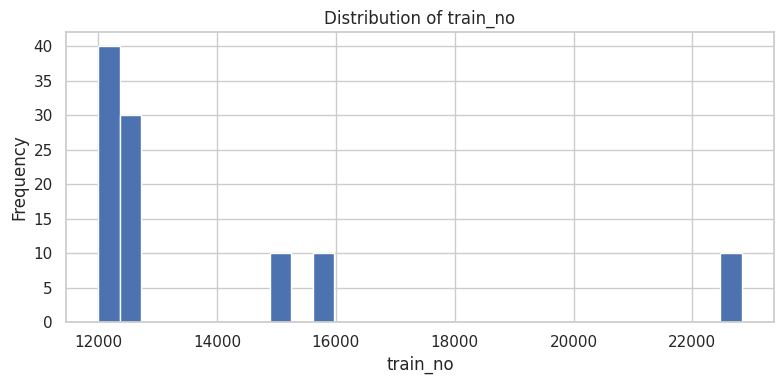

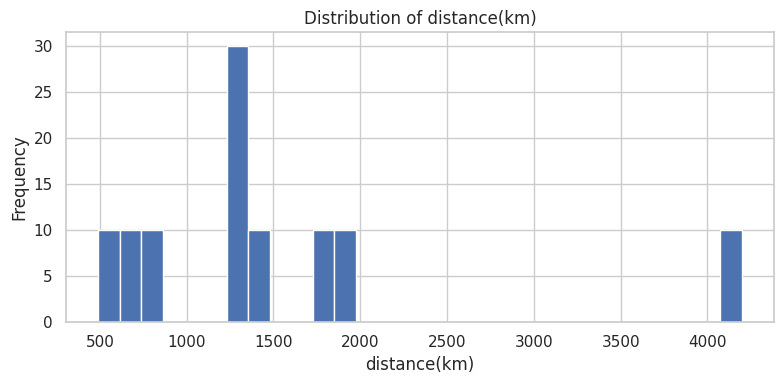

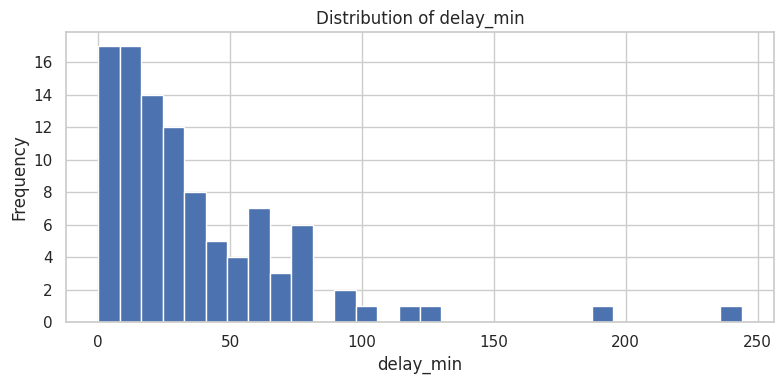

In [50]:
print("Numeric columns:", numeric_cols)

for col in numeric_cols:
    plt.figure(figsize=(8, 4))

    sample = df[col].dropna().sample(
        min(10000, df[col].dropna().shape[0]),
        random_state=42
    )

    plt.hist(sample, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

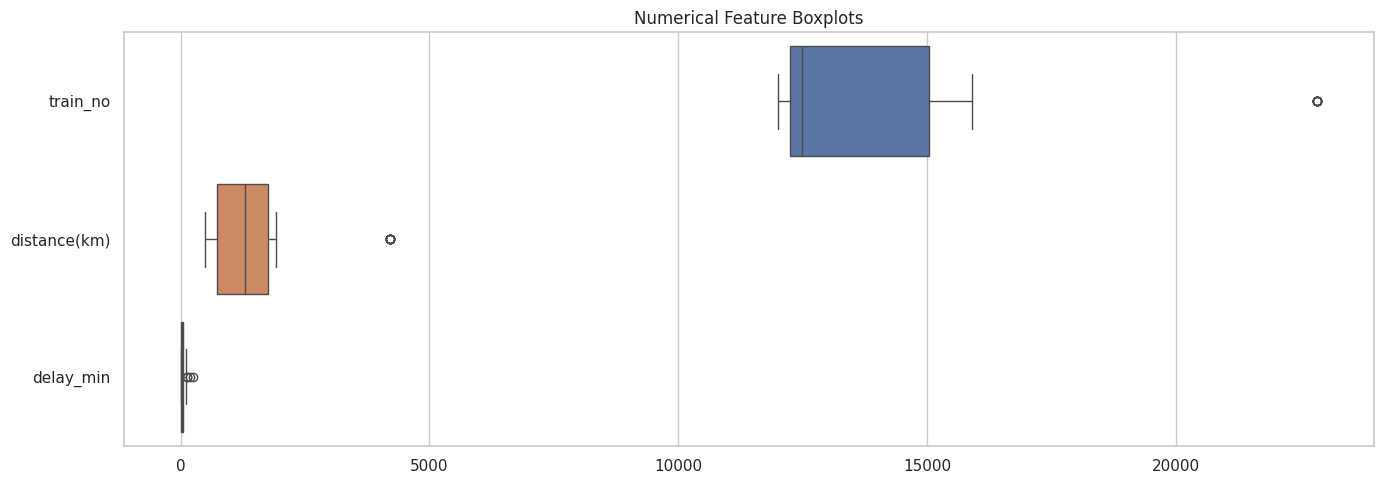

In [51]:

if numeric_cols:
    plt.figure(figsize=(14,max(5,len(numeric_cols)*.6)))
    sns.boxplot(data=df[numeric_cols], orient="h")
    plt.title("Numerical Feature Boxplots")
    plt.tight_layout()
    plt.show()

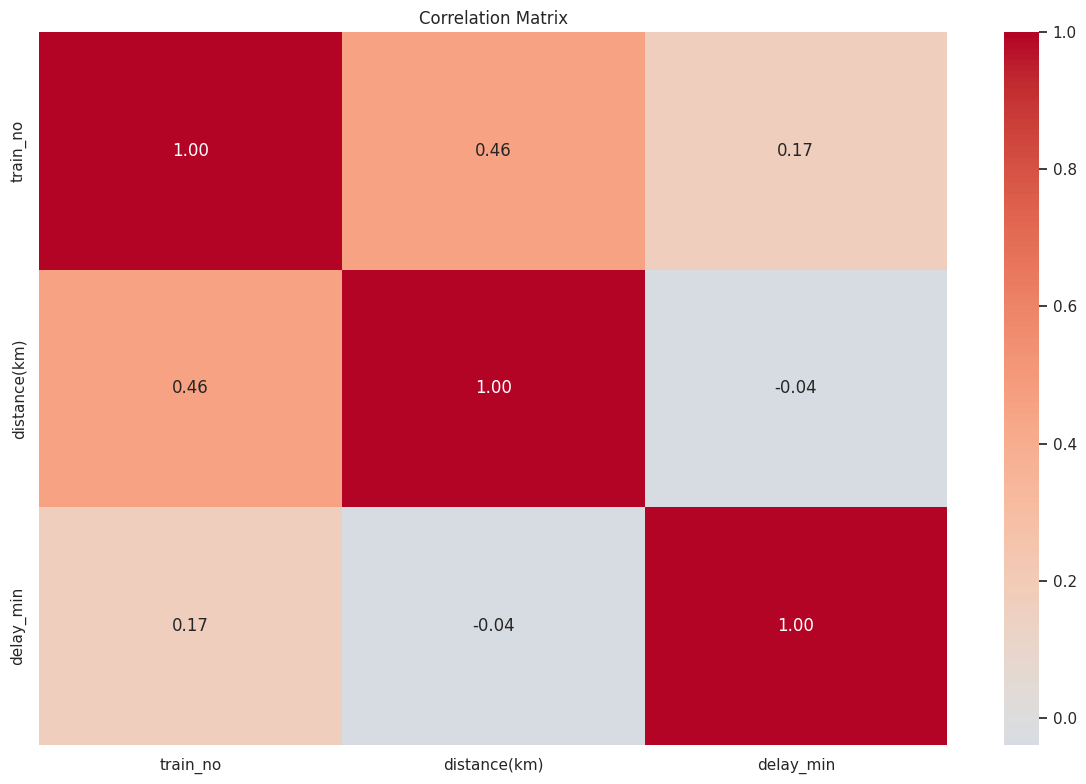

In [52]:

if len(numeric_cols)>=2:
    plt.figure(figsize=(12,8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

In [53]:

categorical_cols = df.select_dtypes(include="object").columns.tolist()
for col in categorical_cols:
    print("\n"+"="*60, "\n", col)
    display(df[col].value_counts().head(20).to_frame("Count"))


 train_id


,Count
train_id,
G10,2
G9,2
G8,2
G7,2
G6,2
G5,2
G4,2
G3,2
G2,2



 train_name


,Count
train_name,
Begampura Express,10
Gorakhpur-pune Weekly Express,10
Rajdhani Express,10
Chennai Express,10
Garib Rath Express,10
Shatabdi Express,10
Lucknow Mail,10
Kanyakumari Express,10
Yesvantpur–Howrah Express,10



 source


...

,Count
route,
Varanasi → Jammu,10
Gorakhpur → Pune,10
Howrah → New Delhi,10
Mumbai → Chennai,10
Kolkata → New Delhi,10
New Delhi → RANI KAMLAPATI,10
Lucknow → New Delhi,10
Chennai Egmore → Kanyakumari,10
Yesvantpur Jn → Howrah,10



 scheduled_arrival_datetime


,Count
scheduled_arrival_datetime,
nan,7
2022-01-01 10:00:00,3
2016-01-01 10:00:00,3
2024-01-01 10:00:00,2
2018-01-01 10:00:00,2
2020-01-01 10:00:00,2
2017-01-01 10:00:00,2
2019-01-01 10:00:00,2
2021-01-01 10:00:00,2



 actual_arrival_datetime


,Count
actual_arrival_datetime,
2023-01-01 08:00:00,2
2017-01-01 06:50:00,1
2016-01-01 07:45:00,1
2018-01-01 08:00:00,1
2019-01-01 06:40:00,1
2021-01-07 06:35:00,1
2020-01-01 07:00:00,1
2022-01-01 07:10:00,1
2024-01-01 06:45:00,1


## 12. Railway column detection
The next cell automatically detects common names. If any result is `None` or incorrect, edit the manual mapping cell below.

In [54]:
def find_column(candidates):
    low = {c.lower(): c for c in df.columns}
    for x in candidates:
        if x.lower() in low: return low[x.lower()]
    for x in candidates:
        for c in df.columns:
            if x.lower() in c.lower(): return c
    return None

train_col = find_column(["train_name","train_number","train_no","train"])
station_col = find_column(["station_name","station","station_code","stop_name"])
scheduled_col = find_column(["scheduled_arrival","scheduled_arrival_time","scheduled_time","arrival_scheduled","sta"])
actual_col = find_column(["actual_arrival","actual_arrival_time","arrival_actual","actual_time","ata"])
delay_col = find_column(["delay_minutes","delay_min","arrival_delay","delay"])

print({"train":train_col,"station":station_col,"scheduled":scheduled_col,"actual":actual_col,"delay":delay_col})

{'train': 'train_name', 'station': None, 'scheduled': 'scheduled_arrival', 'actual': 'actual_arrival', 'delay': 'delay_min'}


In [55]:
# 13. Manual mapping — change only if automatic detection is wrong
# train_col = "YOUR_TRAIN_COLUMN"
# station_col = "YOUR_STATION_COLUMN"
# scheduled_col = "YOUR_SCHEDULED_ARRIVAL_COLUMN"
# actual_col = "YOUR_ACTUAL_ARRIVAL_COLUMN"
# delay_col = "YOUR_DELAY_COLUMN"

print("Current mapping:", train_col, station_col, scheduled_col, actual_col, delay_col)

Current mapping: train_name None scheduled_arrival actual_arrival delay_min


In [56]:

if train_col:
    train_summary = df.groupby(train_col).size().sort_values(ascending=False).reset_index(name="records")
    display(train_summary.head(20))
if station_col:
    station_summary = df.groupby(station_col).size().sort_values(ascending=False).reset_index(name="records")
    display(station_summary.head(20))

,train_name,records
0,Begampura Express,10
1,Chennai Express,10
2,Garib Rath Express,10
3,Gorakhpur-pune Weekly Express,10
4,Kanyakumari Express,10
5,Lucknow Mail,10
6,Rajdhani Express,10
7,Shatabdi Express,10
8,Vivek Express,10
9,Yesvantpur–Howrah Express,10


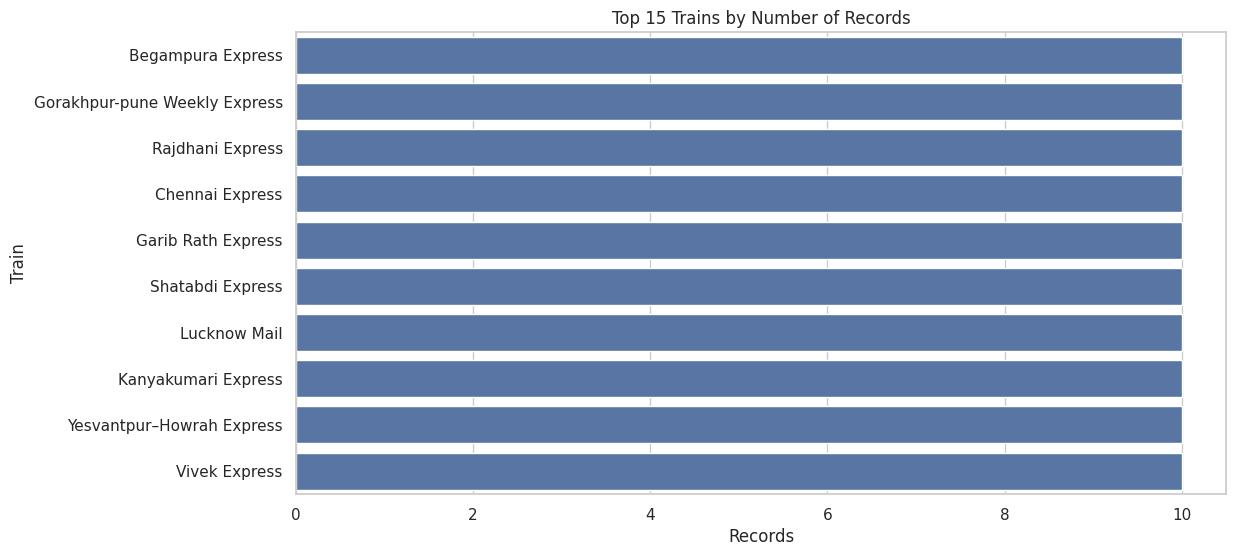

In [57]:

if train_col:
    s=df[train_col].value_counts().head(15)
    plt.figure(figsize=(12,6)); sns.barplot(x=s.values,y=s.index)
    plt.title("Top 15 Trains by Number of Records"); plt.xlabel("Records"); plt.ylabel("Train"); plt.show()

In [58]:

if station_col:
    s=df[station_col].value_counts().head(15)
    plt.figure(figsize=(12,6)); sns.barplot(x=s.values,y=s.index)
    plt.title("Top 15 Stations by Number of Records"); plt.xlabel("Records"); plt.ylabel("Station"); plt.show()

In [59]:

if scheduled_col and actual_col:
    sch=pd.to_datetime(df[scheduled_col].astype(str), errors="coerce")
    act=pd.to_datetime(df[actual_col].astype(str), errors="coerce")
    df["delay_minutes_calculated"]=(act-sch).dt.total_seconds()/60
    overnight=df["delay_minutes_calculated"] < -720
    df.loc[overnight,"delay_minutes_calculated"] += 1440
    print("Calculated delay statistics:")
    display(df["delay_minutes_calculated"].describe())
else:
    print("Scheduled/actual arrival columns not detected.")

Calculated delay statistics:


/tmp/ipykernel_1173/3888428865.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sch=pd.to_datetime(df[scheduled_col].astype(str), errors="coerce")
/tmp/ipykernel_1173/3888428865.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  act=pd.to_datetime(df[actual_col].astype(str), errors="coerce")


,delay_minutes_calculated
count,1.000000e+02
mean,4.663649e+06
std,1.708430e+07
min,0.000000e+00
25%,1.400000e+01
50%,3.000000e+01
75%,6.000000e+01
max,6.662308e+07


In [60]:

analysis_delay_col = delay_col if delay_col else ("delay_minutes_calculated" if "delay_minutes_calculated" in df.columns else None)
print("Delay field:", analysis_delay_col)

Delay field: delay_min


In [61]:

if analysis_delay_col:
    display(df[analysis_delay_col].describe().to_frame("Delay (minutes)"))
    print("Average delay:", round(df[analysis_delay_col].mean(),2), "minutes")
    print("Maximum delay:", round(df[analysis_delay_col].max(),2), "minutes")

,Delay (minutes)
count,100.000000
mean,36.550000
std,38.194445
min,0.000000
25%,10.000000
50%,25.000000
75%,50.000000
max,244.000000


Average delay: 36.55 minutes
Maximum delay: 244.0 minutes


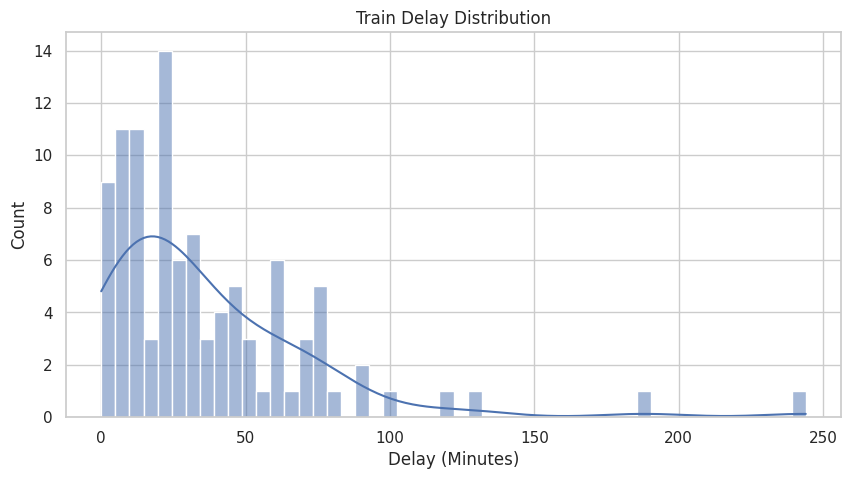

In [62]:
if analysis_delay_col:
    plt.figure(figsize=(10,5)); sns.histplot(df[analysis_delay_col].dropna(), bins=50, kde=True)
    plt.title("Train Delay Distribution"); plt.xlabel("Delay (Minutes)"); plt.show()

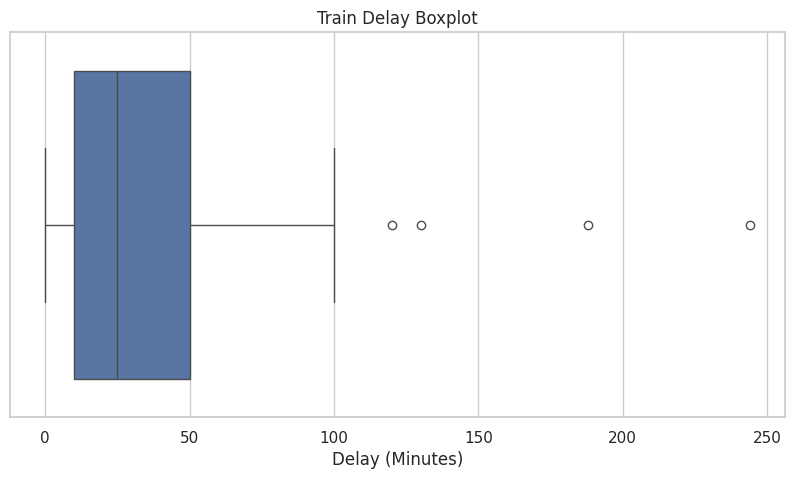

In [63]:
if analysis_delay_col:
    plt.figure(figsize=(10,5)); sns.boxplot(x=df[analysis_delay_col])
    plt.title("Train Delay Boxplot"); plt.xlabel("Delay (Minutes)"); plt.show()

,Average Delay (Minutes)
train_name,
Yesvantpur–Howrah Express,59.1
Gorakhpur-pune Weekly Express,48.5
Begampura Express,42.5
Shatabdi Express,38.9
Rajdhani Express,38.5
Chennai Express,37.5
Garib Rath Express,27.4
Kanyakumari Express,27.2
Lucknow Mail,25.5


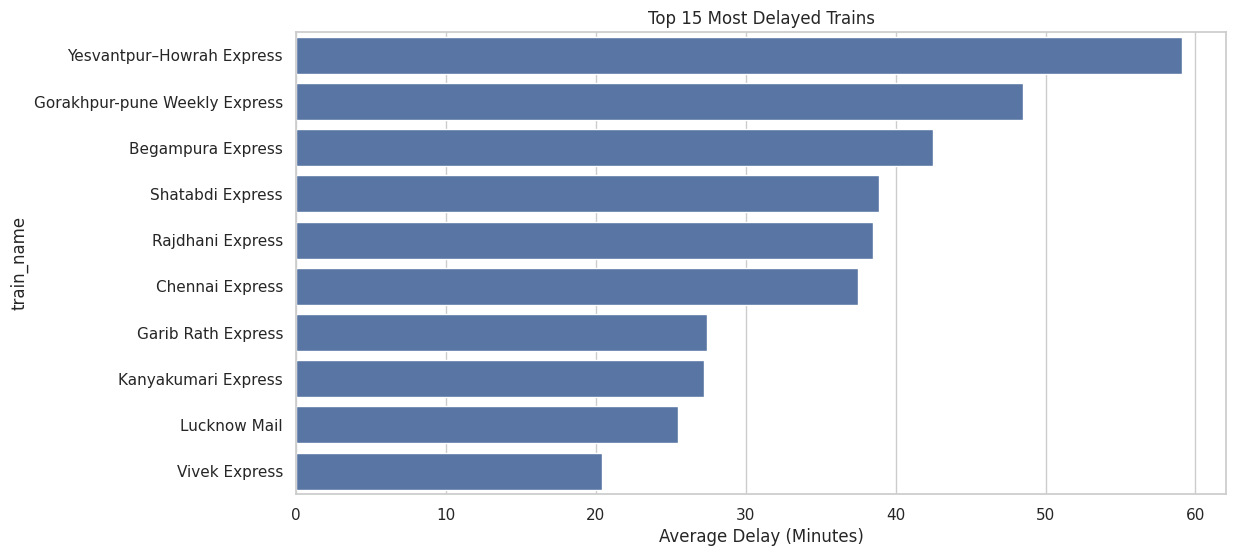

In [64]:
if train_col and analysis_delay_col:
    s=df.groupby(train_col)[analysis_delay_col].mean().sort_values(ascending=False).head(15)
    display(s.to_frame("Average Delay (Minutes)"))
    plt.figure(figsize=(12,6)); sns.barplot(x=s.values,y=s.index)
    plt.title("Top 15 Most Delayed Trains"); plt.xlabel("Average Delay (Minutes)"); plt.show()

In [65]:
if station_col and analysis_delay_col:
    s=df.groupby(station_col)[analysis_delay_col].mean().sort_values(ascending=False).head(15)
    display(s.to_frame("Average Delay (Minutes)"))
    plt.figure(figsize=(12,6)); sns.barplot(x=s.values,y=s.index)
    plt.title("Top 15 Most Delayed Stations"); plt.xlabel("Average Delay (Minutes)"); plt.show()

,count
delay_status,
Delayed,95
On Time,5


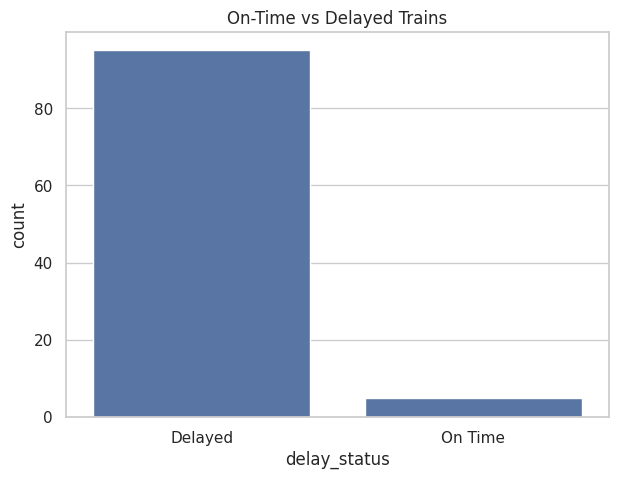

In [66]:
if analysis_delay_col:
    df["delay_status"]=np.where(df[analysis_delay_col]>0,"Delayed","On Time")
    display(df["delay_status"].value_counts())
    plt.figure(figsize=(7,5)); sns.countplot(data=df,x="delay_status")
    plt.title("On-Time vs Delayed Trains"); plt.show()

In [67]:
cols=[c for c in [train_col,station_col,scheduled_col,actual_col,analysis_delay_col] if c]
if cols: display(df[cols].head(30))

,train_name,scheduled_arrival,actual_arrival,delay_min
0,Begampura Express,06:30:00,07:45:00,75.0
1,Begampura Express,06:30:00,06:50:00,20.0
2,Begampura Express,06:30:00,08:00:00,90.0
3,Begampura Express,06:30:00,06:40:00,10.0
4,Begampura Express,06:30:00,07:00:00,30.0
5,Begampura Express,06:30:00,06:35:00,5.0
6,Begampura Express,06:30:00,07:10:00,40.0
7,Begampura Express,06:30:00,08:00:00,90.0
8,Begampura Express,06:30:00,06:45:00,15.0
9,Begampura Express,06:30:00,07:20:00,50.0


In [68]:
if train_col and station_col and analysis_delay_col:
    summary=(df.groupby([train_col,station_col])[analysis_delay_col]
             .agg(records="size",average_delay="mean",maximum_delay="max")
             .reset_index().sort_values("average_delay",ascending=False))
    display(summary.head(30))

In [69]:
print("Final shape:",df.shape)
print("Missing values:",df.isnull().sum().sum())
print("Duplicate rows:",df.duplicated().sum())

Final shape: (100, 19)
Missing values: 0
Duplicate rows: 0


In [70]:
final_file="indian_railway_final_cleaned.csv"
df.to_csv(final_file,index=False)
print("Saved:",final_file)

Saved: indian_railway_final_cleaned.csv
